# Assignment 4
### Do three of four.

### Exercise 1: Contingent Comparisons
- Load the Minnesota use of force data.
- Bootstrap the proportion of missing values for `subject_injury` for each race, and plot the results with grouped KDE and ECDF plots
- Describe what you see. When we consider second order uncertainty, how similar or different are the sampling distributions of these proportions? 

In [1]:
# importing packages 
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt


In [2]:
# loading the minnesota use of force data 
df = pd.read_csv("data/mn_police_use_of_force.csv")

<Axes: ylabel='Proportion'>

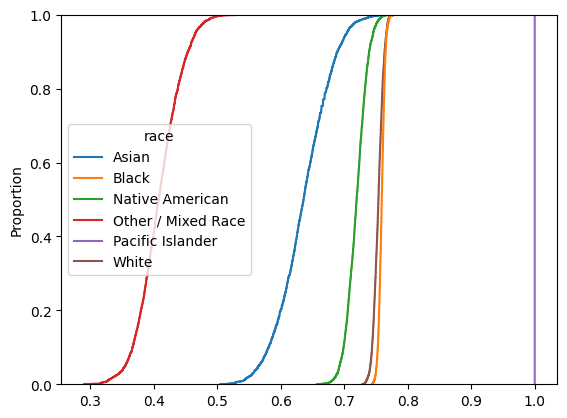

In [ ]:
# df.columns.tolist()
df['missing_inj'] = df['subject_injury'].isna().astype(int)
df['missing_inj']
S = 2500
results = []
for s in range(S):
    sample = df.sample(frac=1.0,replace=True)
    # need to calculate the missing proportions per race 
    miss_pro_per_race = sample.loc[:,['missing_inj','race']].groupby('race').mean()
    results.append(miss_pro_per_race)

estimation = pd.concat([ row for row in results],axis=1).T

sns.ecdfplot(estimation)
## bootstrapping the proportion of missing values for 'subject_injury'
# # going to bootstrap by the mean 


# mean = np.mean(df['missing_inj'])

# def bootstrap(data, mean, plot=True):
#     bootstrap_estimates= [mean(data.sample(frac=1.0,replace=True))for entry in range(1000)]

    
#     if plot:
#         fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # 1 row, 2 columns
#         sns.kdeplot(x, ax = axes[0]).set(title='KDE of Underlying Data')
#         sns.kdeplot(bootstrap_estimates, ax = axes[1]).set(title='KDE of Computed Statistics')
#         axes[1].axvline(x=mean(data), color='orange', linestyle='--')
#         sns.ecdfplot(bootstrap_estimates, ax = axes[2]).set(title='ECDF of Computed Statistics')
#         axes[2].axvline(x=mean(data), color='orange', linestyle='--')
#         plt.show()
#         print(f'Variance of estimates is: {np.var(bootstrap_estimates)}')

# estimates = bootstrap(df['missing_inj'], mean)

### Exercise 2: Invitation to Inference
- Run the simulation code line by line and comment what each line is doing, or write your own code to do the resampling
- Open the NHANES or Ames prices or College Completion data. Pick a variable and a statistic to compute (e.g. mean, median, variance, IQR)
- Use the `simulate` function from class to get a sample of estimates for your statistic and your data
- Create a new function, `interval(L,H,estimates)`, that computes the $L$-th and $H$-th quantiles for your estimates, $H>L$
- If $L=.05$ and $H=.95$, this is a **90-percent confidence interval**: "For our statistic, this interval captures the true value of the population parameter 90 percent of the time. (We are 90% **confident** that it includes the true value of the parameter, but the probability that the true parameter lies in this interval is 0 or 1.)"
- We will spend much more time on this later in class, but for people who have done hypothesis testing before, you now know how to do it directly from the data: No central limit theorem required.

In [48]:
# okay going to use the previous code to do the resampling 
# first going to open the dataset of my choosing - AMES
ames = pd.read_csv('data/ames_prices.csv')
# going to do the price variable 
reg_mean = ames['price'].mean()
reg_mean

180796.0600682594

In [58]:
#going to bootstrap the mean of the price variable

S = 2500
price_mean_results = []
for s in range(S):
    sample = ames['price'].sample(frac=1.0,replace=True)
    # need to calculate the missing proportions per race 
    sample_mean = sample.mean()
    price_mean_results.append(sample_mean)

# price_mean_results


(178345.73435153585, 183194.33407849827)


<Axes: ylabel='Density'>

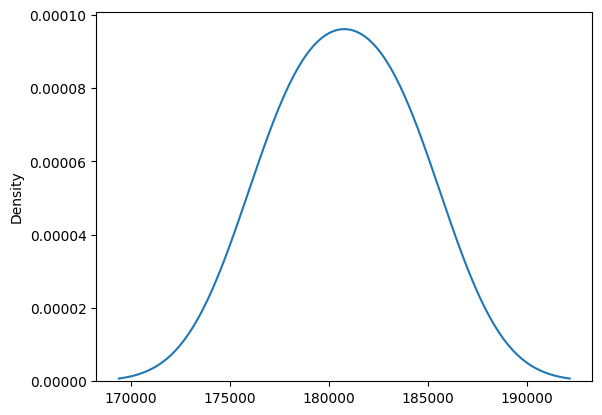

In [64]:
def interval(L,H,estimates):
    # h must be greater than l
    lower_quant = np.quantile(estimates,L)
    higher_quant = np.quantile(estimates,H)
    return lower_quant, higher_quant


trial = interval(.05,.95,price_mean_results)
print(trial)
sns.kdeplot(trial)

### Exercise 3: Intro to A/B Testing
- Go here, and read about this study: https://www.clinicaltrials.gov/study/NCT01985360
- Read the Study Overview and explain what the goal of the trial is 
- Read the Study Plan and explain how it was designed and why -- there's lots of medical jargon, but the main point is how patients were assigned to interventions. 
- Read the Results Posted: Go to **Outcome Measures**. Explain how table 1 ("Incidence of Death from Any Cause or Myocardial Infarction") is a contingency table. These are the data for this exercise.
- What is the difference in surival rates between the invasive strategy and the conservative strategy?
- Bootstrap the survival rates for the two groups, and plot them as KDEs and ECDFs against one another
- Bootstrap the difference in surival rates, and plot it as a KDE and ECDF
- Is this an effective health intervention? Explain your answer clearly

This would be what CS people call **A/B testing** and everyone else called a **randomized controlled trial**: Using randomized assignment to detect the difference in outcomes between two groups. (We've just done a non-parametric version of a two-sample t-test.)

The goal of the trial is to determine the best management strategy for patients with stable ischemic heart disease. These individuals must have also had advanced chronic kidney disease and moderate inducible ischemia. 

The study plan follows randomized allocation and parallelt assignment. In more plain language, particpants are randomly assigned to a treatment group (nothing but change/randominess determines their group allocation). After everyone was randomly assigned to a group, each group is given a different treatment on the same chronological schedule with the other group. 

The specific parallel treatments that each group received was either the invasive strategy or conservative strategy. The invasive strategy consisted is opening narrowed blood vessels followed by creating an arterty bypass or a stent is inserted to push against the artery wall. Both the artery bypass and stent allow for better blood flow and both of these groups had medical therapy after they had the procedure that was meant to improve their blood flow. The other group, the conservative strategy, only received medical therapy.

Table 1 is a contingency table because contingency tables are visualizatons that communicate the frequency distribution of two intersecting variables. The table in the outcome measures is a contingency table because it depicts the frequency of death from any cause or myocardial infarction in the invasive strategy group and the conservative strategy group. In addition to incidence, the table also depicts the total number of participants. 



 

In [25]:
# translating the data
# starting with the invasive strategy
invasive_total = np.ones(388)
invasive_dead = 123
invasive_total[:invasive_dead] = 0

invasive_dict = pd.DataFrame({'Group Allocation':'Invasive','Outcome':invasive_total})

# moving on to the conservative strategy
conservative_total = np.ones(389)
conservative_dead = 129
conservative_total[:conservative_dead] = 0

conservative_dict = pd.DataFrame({'Group Allocation':'Conservative','Outcome':conservative_total})
# going to make this entire thing a 

health_df=pd.concat([invasive_dict,conservative_dict])
health_df

,Group Allocation,Outcome
0,Invasive,0.0
1,Invasive,0.0
2,Invasive,0.0
3,Invasive,0.0
4,Invasive,0.0
...,...,...
384,Conservative,1.0
385,Conservative,1.0
386,Conservative,1.0
387,Conservative,1.0


In [26]:
# making a contingency table to look at the survival rates
survival_rates = health_df.groupby('Group Allocation')['Outcome'].mean()
survival_rates

Group Allocation
Conservative    0.66838
Invasive        0.68299
Name: Outcome, dtype: float64

The conservative group had a 66.83% survival rate while the invasive group had a 68.29% survival rate.

<Axes: ylabel='Proportion'>

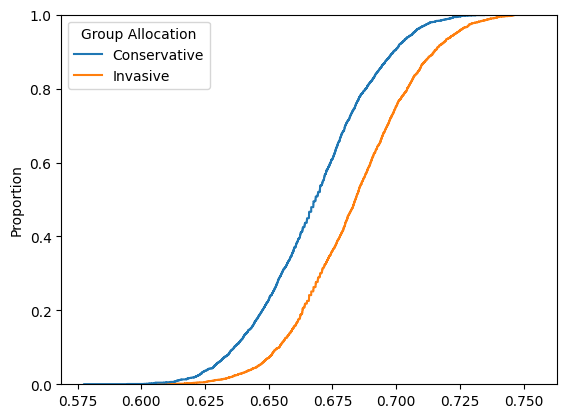

In [27]:
# attempting to bootstrap the survival rates
S = 2500
health_results = []
for s in range(S):
    sample = health_df.sample(frac=1.0,replace=True)
    # need to calculate the missing proportions per race 
    survival_sample = sample.groupby('Group Allocation')['Outcome'].mean()
    health_results.append(survival_sample)

health_estimation = pd.concat([ row for row in health_results],axis=1).T

sns.ecdfplot(health_estimation)

<Axes: ylabel='Density'>

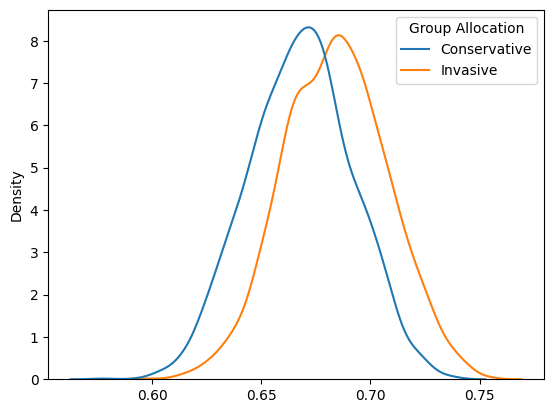

In [28]:
# lets plot the kde now 
sns.kdeplot(health_estimation)

In [31]:
sample['Group Allocation']

187    Conservative
235        Invasive
382    Conservative
167        Invasive
236    Conservative
           ...     
8      Conservative
262    Conservative
309        Invasive
6      Conservative
167    Conservative
Name: Group Allocation, Length: 777, dtype: object

In [37]:
np.set_printoptions(legacy='1.25')

In [ ]:
# attempting to bootstrap the difference in survival rates 

S = 2500
surv_diff = []
for s in range(S):
    # sample = health_df.sample(frac=1.0,replace=True)
    # subsetting the data 
    consv_survival_sample = conservative_dict['Outcome'].sample(frac=1.0,replace=True).mean()
    invas_survival_sample = invasive_dict['Outcome'].sample(frac=1.0,replace=True).mean()
    surv_ex =  invas_survival_sample - consv_survival_sample
    surv_diff.append(surv_ex)

# surv_diff 
# okay it is saying np.float in the surv_diff so i need to remove that from the output 
# surv_diff


<Axes: ylabel='Proportion'>

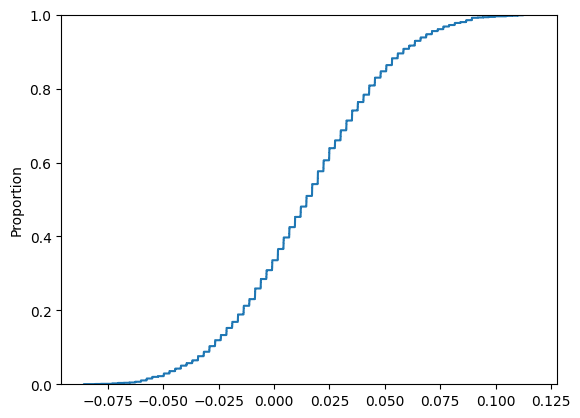

In [56]:
sns.ecdfplot(surv_diff)

<Axes: ylabel='Density'>

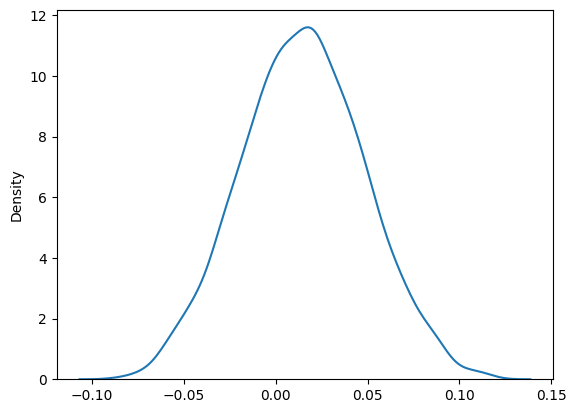

In [57]:
sns.kdeplot(surv_diff)

After analyzing all the visualizations, I would say that the invasive strategy is not a statistically siginificant intervention. When plotting the differences between the invasive and conservative strategies survival rate there are small differences. More specifically, when one looks at the KDE plot that depicts the difference between the conservative and invasive strategies survival rate, we see that the greatest density falls between 0.00 and 0.05 highlighting, that there is a very small difference in the survival rates, with the invasive strategy sometimes producing a better survival rate but never more than 0.10. Next, when looking at the ECDF that depicts both suurvival rates for the invasive and conservative strategies, there is also only a small difference. For example, when looking at 80% percent of the conservative strategy had a survival rate of around 67% and the invasive strategy had only a survival rate of aroun 70%. These numbers are pretty close lead me to assume that the invasive strategy is not the most effective. However,I think it is important to note that different statistical fields have different staistically significant thresholds. While the overall survival rate increase (when bootstrapped) is only around 3%, this 3% difference could be significant in the medical field depending on the thresholds they have. 


### Exercise 4: Prediction Uncertainty
- Pick a dataset and two continuous variables.
- Recall the LCLS estimator:
$$
\hat{y}(z) =  \frac{ \frac{1}{N} \sum_{i=1}^N y_i \times \frac{1}{h}k\left( \frac{z - x_i}{h} \right)}{ \frac{1}{N} \sum_{i=1}^N \frac{1}{h} k\left( \frac{z - x_i}{h} \right)}
$$
with the Epanechnikov kernel and the standard plug-in bandwidth for $h$
- Compute and plot this line for 30 bootstrap samples. Notice where there is a lot of variation in the predictions, versus little variation in the predictions.
- Now, for any $z$, we can bootstrap a distribution of predictions using the above formula. Do this at the 25th percentile, median, and 75th percentile of $X$, and make KDE plots of your results.
- Now, pick a grid for $z$: Obvious choices are all of the unique values in the data, or an equally spaced grid from the minimum value to the maximum value. For each $z$, bootstrap a sample of predictions and compute the .05 and .95 quantiles. Plot these error curves along with your LCLS estimate. Where are your predictions "tight"/reliable? Where are they highly variable/unreliable?